# Deflection ΔV Calculator Example Notebook

This notebook calls functions provided in **deflection_propogation.py** to calculate the minimum ΔV (and corresponding time) required to deflect a heliocentric body to some distance away from a main heliocentric body on the Opik B-Plane.

Both **kinetic** and **continuous** impulse deflection examples are shown below.

#### Imports

In [43]:
from deflection_propogation import (
    au2km,
    au_per_day2km_per_s,
    determine_impact,
    search_best_continuous_start_time,
    search_best_impulse_time,
    plot_bplane,
)

#### Orbital Elements & Deflection Parameters

In [44]:
elements_target = [9.78969676e-1, 1.83889630e-2, 7.55697209e-5, 5.34322623, 2.63906227, 1.88972281]  # q [AU], e, i [rad], w [rad], Omega [rad], M [rad]
elements_asteroid = [0.74161536, 0.19293483, 0.05877868, 2.22509624, 3.55784498, 3.64624167]  # q [AU], e, i [rad], w [rad], Omega [rad], M [rad]

mu_sun = 0.0002959112271132008       # AU^3 / day^2
mu_target = 8.8877e-10               # AU^3 / day^2
R_target = 0.0000426354              # AU
R_target_sof = 0.006216666023709612  # AU

t_max = 365.0               # max time frame to search for impact [days]
dt_search_imp = 5.0         # impulse time step for searching for impact [days]
dt_search_kin = 2.0         # kinematic time step for searching for impact [days]
b_target = 4.0 * R_target   # target b-plane radius for impact [AU]

#### Time Entering Sphere of Influence (for time search optimization)

In [45]:
t_sof_nominal = determine_impact(elements_target, elements_asteroid, mu_sun, R_target_sof, t_max, 1.0)
if t_sof_nominal is None:
    raise RuntimeError("No nominal SOF crossing found in the search window.")
print(f"Nominal SOF-entry time: {t_sof_nominal:.6f} days")

Nominal SOF-entry time: 358.174729 days


---
## Continuous Deflection Example

In [ ]:
best_continuous_deflections = {}
for direction in ["transverse", "radial", "normal"]:
    best_continuous_deflections[direction] = search_best_continuous_start_time(
        elements1=elements_target,   # orbital elements of the main body at the common initial epoch
        elements2=elements_asteroid, # orbital elements of the secondary at the same initial epoch
        mu1=mu_sun,                  # gravitational parameter of the central body (Sun) in AU^3/day^2
        mu2=mu_target,               # gravitational parameter of the main body in AU^3/day^2
        R_planet=R_target,           # physical radius of the main body in AU
        R_sof=R_target_sof,          # sphere-of-influence / encounter radius of the main body in AU
        direction=direction,         # impulse direction to test: "transverse", "radial", or "normal"
        b_target=b_target,           # required minimum b-plane miss distance in AU
        t_start_min=0.0,           # earliest allowed impulse time [days from the common epoch]
        t_start_max=t_sof_nominal, # latest allowed impulse time [days from the common epoch], default is nominal SOF entry
        t_max=t_max,                 # maximum time [days from common epoch] allowed for internal SOF-crossing search
        dt=dt_search_imp,                # timestep [days] used when scanning forward in time to locate SOF crossing
        coarse_step=40.0,            # coarse impulse-time grid spacing [days] for first pass of the search
        mid_half_width=4.0,          # half-width [days] of the medium-refinement window around the best coarse time
        mid_step=3.0,                # medium-refinement grid spacing [days]
        fine_half_width=0.5,         # half-width [days] of the final fine-refinement window around the best medium time
        fine_step=0.5,               # fine-refinement grid spacing [days]
    )

for direction, sol in best_continuous_deflections.items():
    sign_label = "+" if sol["deltaV"] >= 0 else "-"
    print(
        f"{direction:>10s} continuous:"
        f"  sign = {sign_label},"
        f"  t_start = {sol['t_start']:.6f} d,"
        f"  deltaV_min = {au_per_day2km_per_s(abs(sol['deltaV'])):.6e} km/s"
    )

#### B-Plane Plot

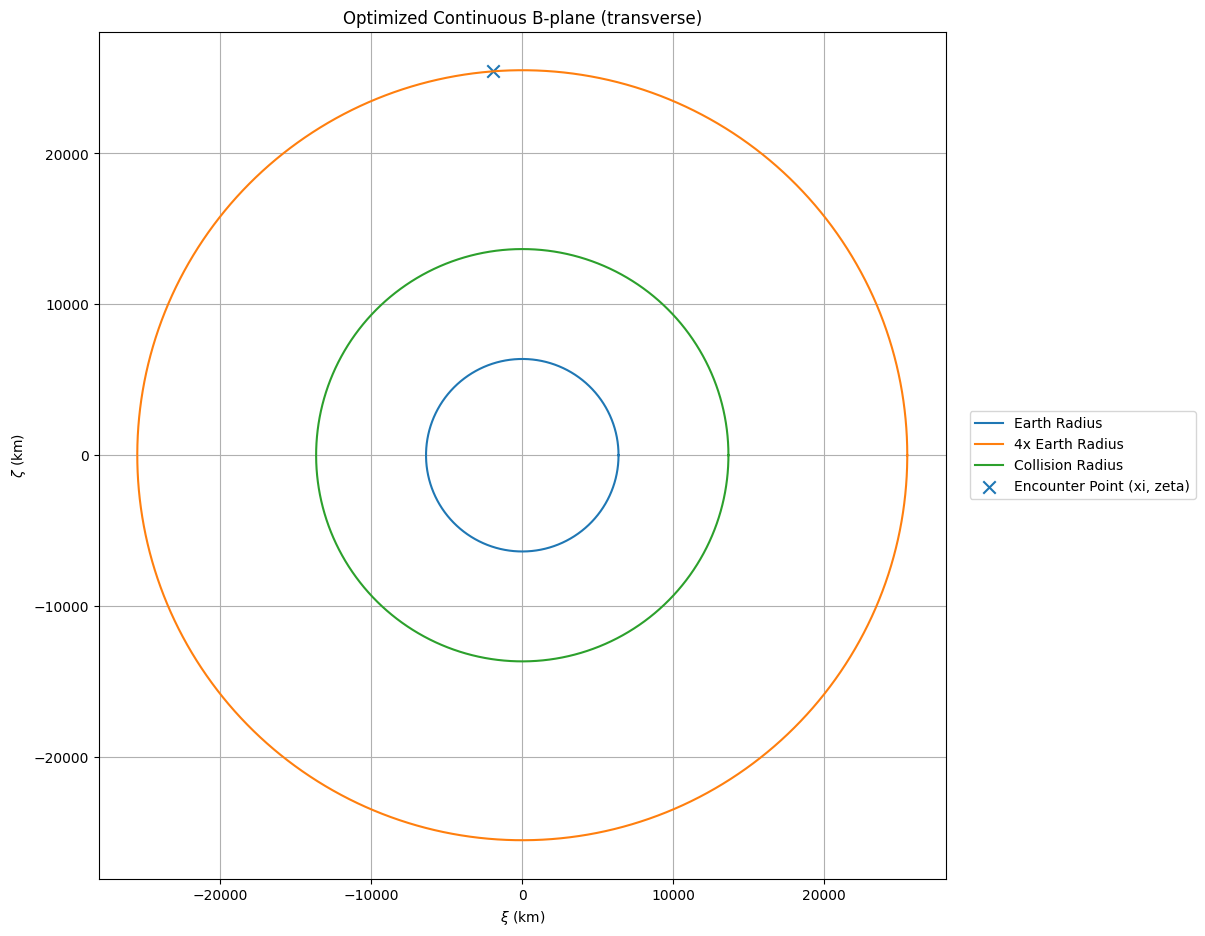

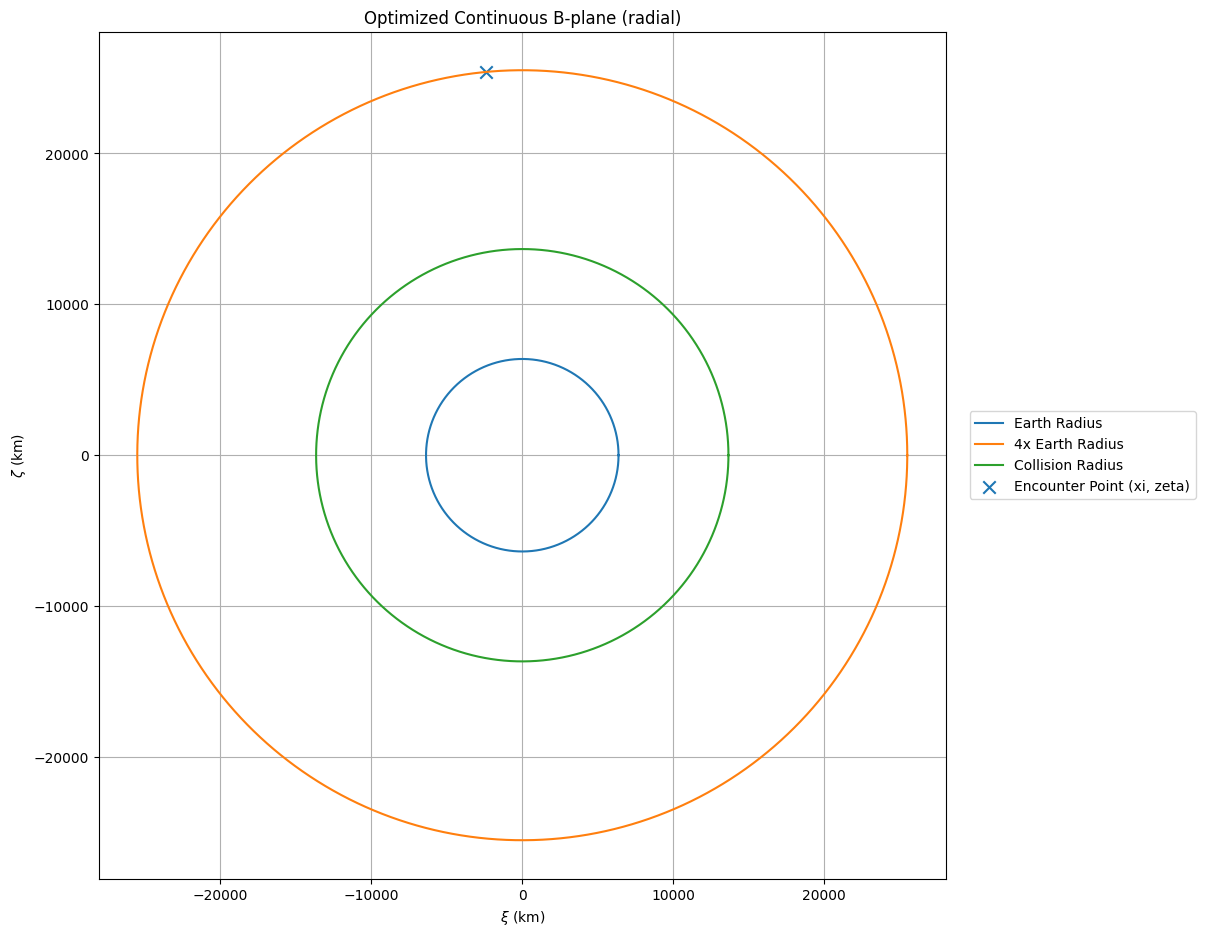

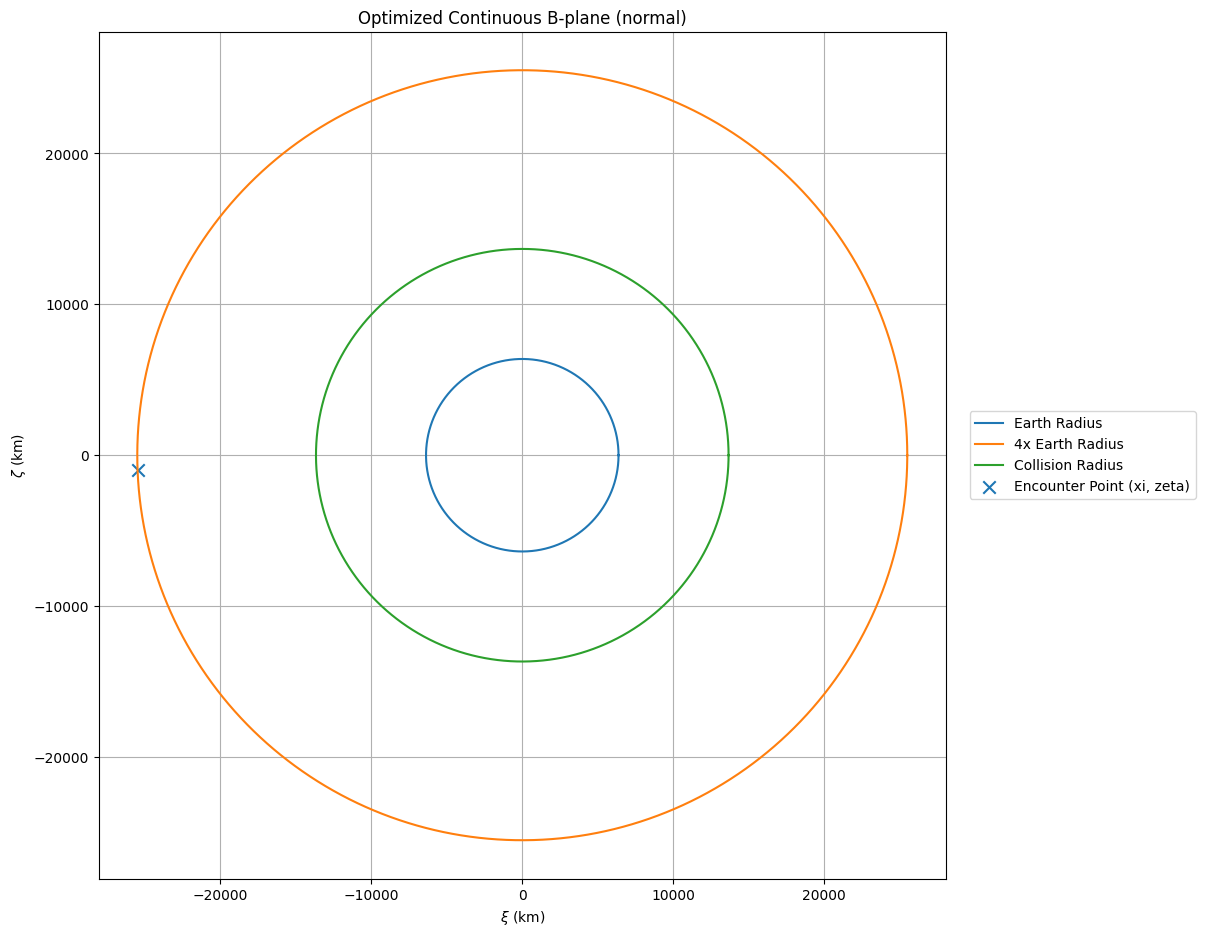

In [ ]:
for direction, sol in best_continuous_deflections.items():
    xi, zeta, _, b_coll = sol["b_elems"][:4]
    plot_bplane(au2km(xi), au2km(zeta), au2km(b_coll), au2km(R_target), title=f"Optimized Continuous B-plane ({direction})", units_in_km=True)

---
## Kinetic Deflection Example

In [ ]:
best_impulse_deflections = {}
for direction in ["transverse", "radial", "normal"]:
    best_impulse_deflections[direction] = search_best_impulse_time(
        elements1=elements_target,   # orbital elements of the main body at the common initial epoch
        elements2=elements_asteroid, # orbital elements of the secondary at the same initial epoch
        mu1=mu_sun,                  # gravitational parameter of the central body (Sun) in AU^3/day^2
        mu2=mu_target,               # gravitational parameter of the main body in AU^3/day^2
        R_planet=R_target,           # physical radius of the main body in AU
        R_sof=R_target_sof,          # sphere-of-influence / encounter radius of the main body in AU
        direction=direction,         # impulse direction to test: "transverse", "radial", or "normal"
        b_target=b_target,           # required minimum b-plane miss distance in AU
        t_impulse_min=0.0,           # earliest allowed impulse time [days from the common epoch]
        t_impulse_max=t_sof_nominal, # latest allowed impulse time [days from the common epoch], default is nominal SOF entry
        t_max=t_max,                 # maximum time [days from common epoch] allowed for internal SOF-crossing search
        dt=dt_search_kin,            # timestep [days] used when scanning forward in time to locate SOF crossing
        coarse_step=20.0,            # coarse impulse-time grid spacing [days] for first pass of the search
        mid_half_width=6.0,          # half-width [days] of the medium-refinement window around the best coarse time
        mid_step=3.0,                # medium-refinement grid spacing [days]
        fine_half_width=1.0,         # half-width [days] of the final fine-refinement window around the best medium time
        fine_step=0.5,               # fine-refinement grid spacing [days]
    )

for direction, sol in best_impulse_deflections.items():
    sign_label = "+" if sol["dV_min"] >= 0 else "-"
    print(
        f"{direction:>10s} impulse:"
        f"  sign = {sign_label},"
        f"  t_impulse = {sol['t_impulse']:.6f} d,"
        f"  deltaV_min = {au_per_day2km_per_s(abs(sol['dV_min'])):.6e} km/s"
    )

transverse impulse:  sign = -,  t_impulse = 113.000000 d,  deltaV_min = -2.853366e-04 km/s
    radial impulse:  sign = -,  t_impulse = 184.000000 d,  deltaV_min = -1.044132e-03 km/s
    normal impulse:  sign = -,  t_impulse = 257.000000 d,  deltaV_min = -4.692725e-03 km/s


#### B-Plane Plot

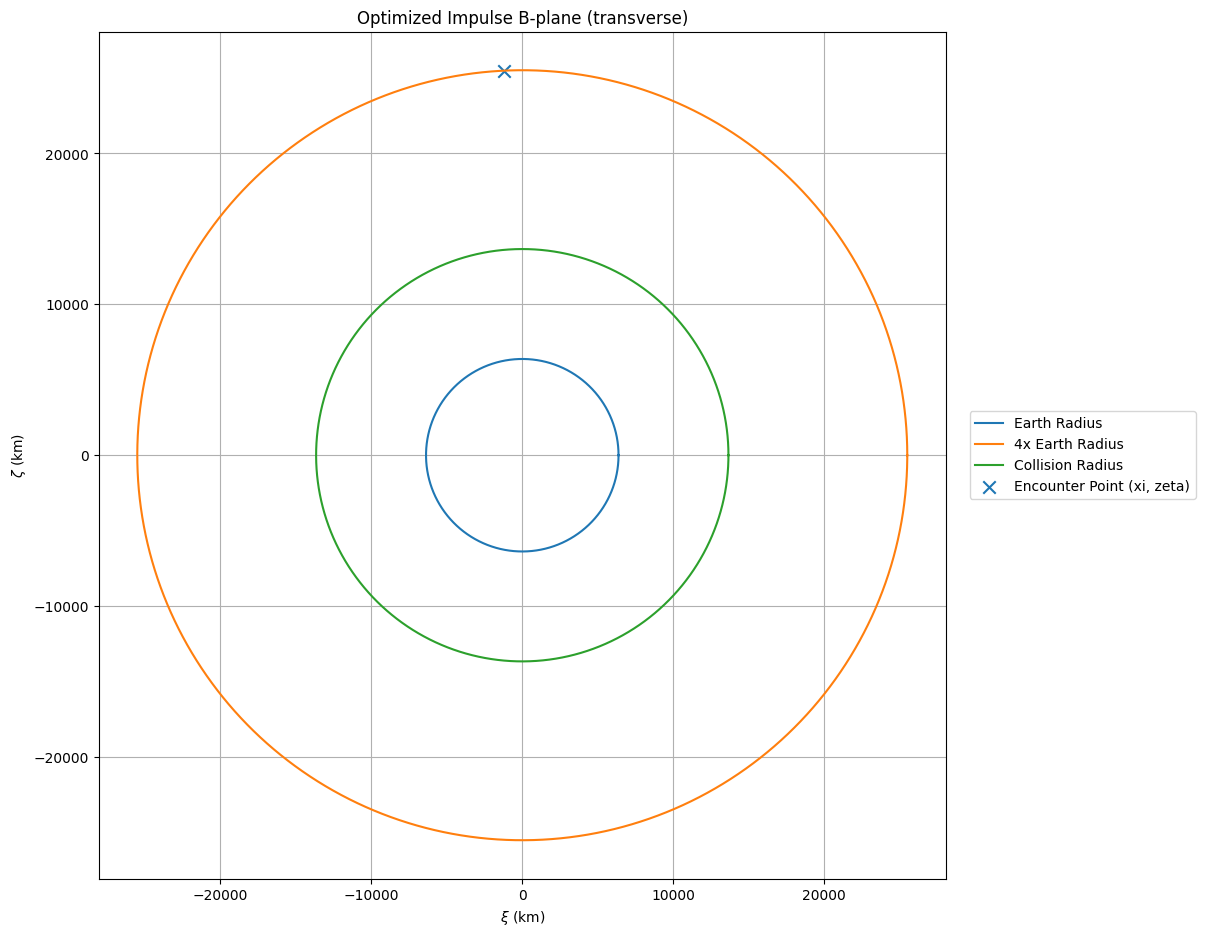

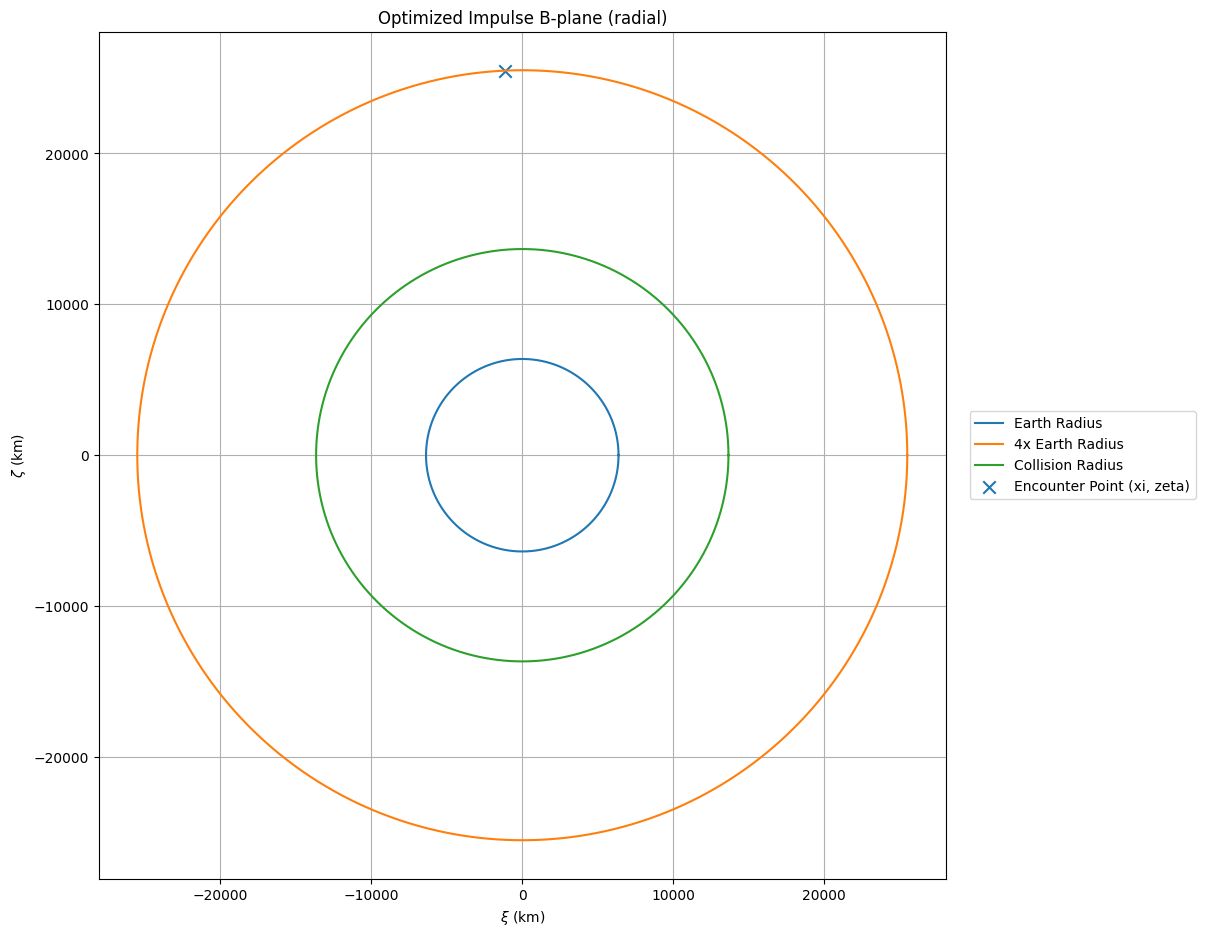

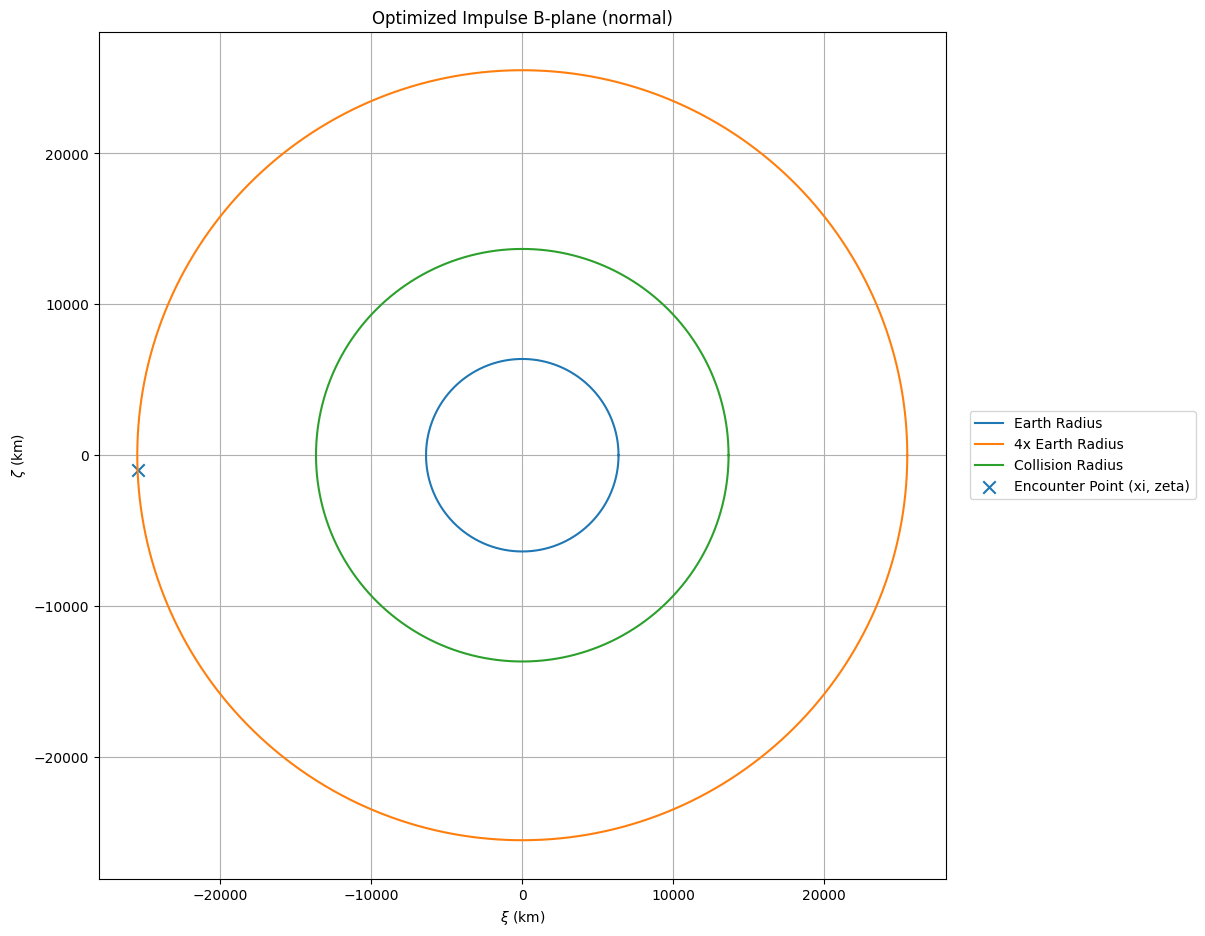

In [ ]:
for direction, sol in best_impulse_deflections.items():
    xi, zeta, _, b_coll = sol["b_elems"][:4]
    plot_bplane(au2km(xi), au2km(zeta), au2km(b_coll), au2km(R_target), title=f"Optimized Impulse B-plane ({direction})", units_in_km=True)